# Parameters

In [1]:
from common.utils.parameters import (
    omega_c,
)
from common.utils.phases import default_three_phase_protocol
from parser.moments import MomentSeries

from pathlib import Path

%reload_ext autoreload
%autoreload 2

output_dir = Path("output")

### Parameters

In [2]:
# common fixed
Gamma = 1; dt = 1e-2; num_snapshots=100
# param
dN = 0
Ni = [10,10]
omega_i = [0.7]
ntraj = 100
# Model and parameters
Omega_ratio = 0.4
Omega0 = Omega_ratio * omega_c(sum(Ni)//2, Gamma)
delta0 = 1
# protocol phases
phases = default_three_phase_protocol(
    T1=10.0,
    T2=10.0,
    T3=10.0,
    delta0=delta0,
    Omega0=Omega0,
)

total_time = float(sum(phase.duration for phase in phases))

### Mean-field Equations

In [3]:
from solvers.mfe import compute_mfe_j_moments, solve_mfe
from parser.mfe import MFESolverParameters

# moment initialization
mfe_moments = MomentSeries(
    num_snapshots=num_snapshots,
    total_time=total_time,
    )

# Define method parameters and solve using mean-field equations
mfe_parameters = MFESolverParameters(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    phases=phases,
)
mfe_result = solve_mfe(
    mfe_parameters,
    t_eval=mfe_moments.t,
)

# compute moments
mfe_moments.J = compute_mfe_j_moments(mfe_result)

### Monte-Carlo Wave Function

In [4]:
from parser.mcwf import MCWFSolverParameters
from solvers.mcwf.ensamble_sim import run_trajectory_ensemble
from solvers.mcwf.j_moments import compute_mcwf_j_moments

# moment initialization
mcwf_moments = MomentSeries(
    num_snapshots=num_snapshots,
    total_time=total_time,
    )

# Define method parameters and simulate using Monte-Carlo wave function method
mcwf_parameters = MCWFSolverParameters(
    Ni=Ni,
    dN=dN,
    omega_i=omega_i,
    Gamma=Gamma,
    phases=phases,
    sector_distribution="binomial",
    dt=dt,
    shifted_jump_operator=True,
)
mcwf_ensemble = run_trajectory_ensemble(
    mcwf_parameters,
    t_eval=mcwf_moments.t,
    seed=1234,
    ntraj=ntraj,
    n_processes=-1,
    )

# compute moments
mcwf_moments.J = compute_mcwf_j_moments(
    mcwf_ensemble,
    n_processes=-1,
)

/Users/ashar/.pyenv/versions/cavity-OAT_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
simulate trajectories: 100%|██████████| 100/100 [00:01<00:00, 57.38it/s]


Simulation step summary (avg per trajectory): total steps=3084.93, steps without precompute=114.92


compute_mcwf_j_moments: 100%|██████████| 100/100 [00:01<00:00, 67.79it/s]


### Qutip (mesolve & mcsolve)

In [5]:
from parser.qutip import QutipMCSolverParameters, QutipMESolverParameters
from solvers.qutip_fixed_nj.sim import (
    simulate_fixed_nj_mc_trajectory,
    simulate_fixed_nj_me_trajectory
)
from solvers.qutip_fixed_nj.j_moments import compute_qutip_j_moments

# moment initialization
me_qutip_moments = MomentSeries(
    num_snapshots=num_snapshots,
    total_time=total_time,
    )
mc_qutip_moments = MomentSeries(
    num_snapshots=num_snapshots,
    total_time=total_time,
    )

# define method parameters and solve using Qutip 
#   - master equation solver
#   - quantum trajectory solver
me_qutip_parameters = QutipMESolverParameters(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    phases=phases,
    shifted_jump_operator=True,
)
mc_qutip_parameters = QutipMCSolverParameters(
    Ni=tuple(Ni),
    omega_i=tuple(omega_i),
    Gamma=Gamma,
    phases=phases,
    shifted_jump_operator=True,
)
me_qutip_ensamble = simulate_fixed_nj_me_trajectory(
    me_qutip_parameters,
    num_points=600,
)
mc_qutip_ensamble = simulate_fixed_nj_mc_trajectory(
    mc_qutip_parameters,
    num_points=600,
    ntraj=ntraj,
    seed=1234,
    n_processes=-1,
)

# compute moments
me_qutip_moments.J = compute_qutip_j_moments(
    me_qutip_ensamble,
)
mc_qutip_moments.J = compute_qutip_j_moments(
    mc_qutip_ensamble,
)

Using QuTiP master equation solver fixed 2-group sector NJi=[5, 5] with Ni=[10, 10] and omega_i=(0.7, 1.3).
Using QuTiP quantum trajectories fixed 2-group sector NJi=[5, 5] with Ni=[10, 10] and omega_i=(0.7, 1.3).


### Plotting

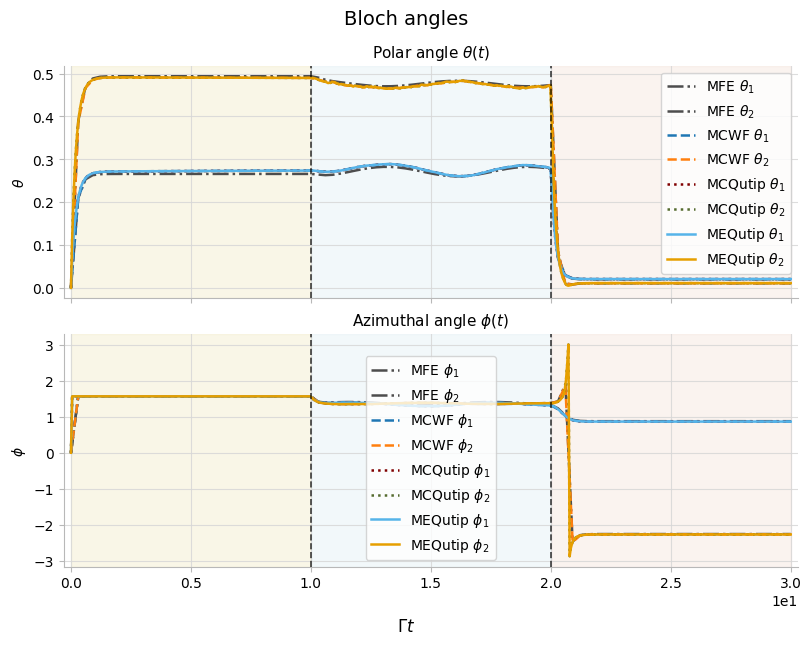

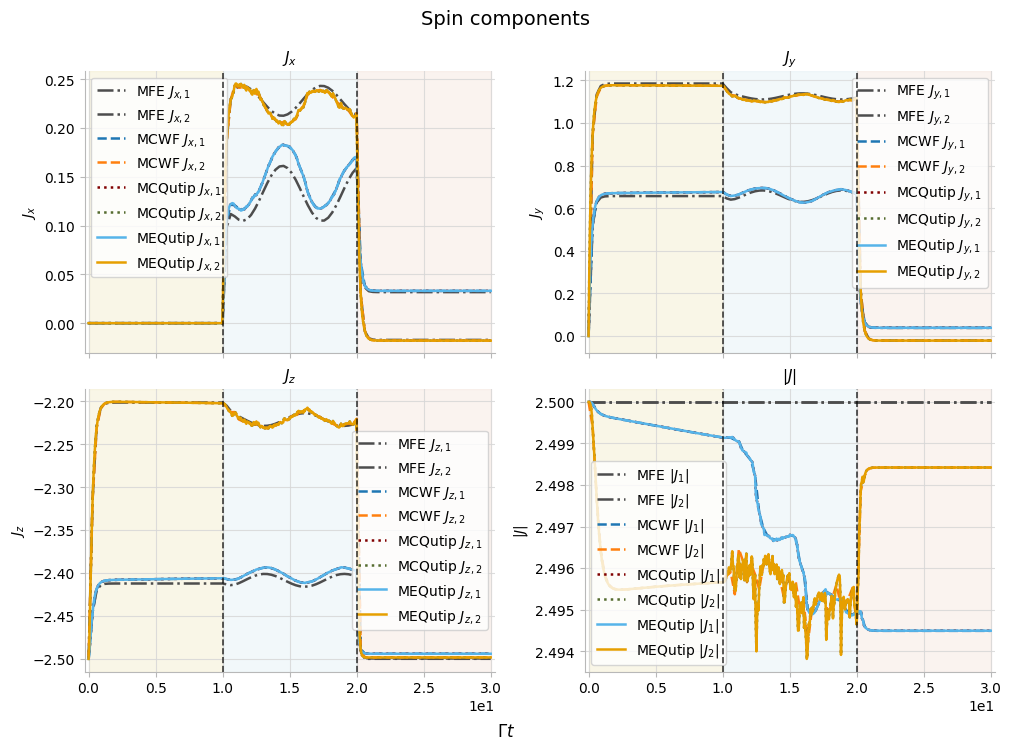

In [6]:
from common.plotting import (
    plot_bloch_angles,
    plot_spin_components,
)


fig, axes = plot_bloch_angles(
    mfe_moments.J,
    phases=phases,
    label="MFE",
    colour_index=4,
    linestyle="-.",
)
fig, axes = plot_bloch_angles(
    mcwf_moments.J,
    phases=phases,
    label="MCWF",
    colour_index=0,
    linestyle="--",
    axes=axes
)
fig, axes = plot_bloch_angles(
    mc_qutip_moments.J,
    phases=phases,
    label="MCQutip",
    colour_index=1,
    linestyle=":",
    axes=axes
)
fig, axes = plot_bloch_angles(
    mc_qutip_moments.J,
    phases=phases,
    label="MEQutip",
    colour_index=2,
    linestyle="-",
    axes=axes
)


fig, axes = plot_spin_components(
    mfe_moments.J,
    normalized=False,
    phases=phases,
    label="MFE",
    colour_index=4,
    linestyle="-.",
)
fig, axes = plot_spin_components(
    mcwf_moments.J,
    normalized=False,
    phases=phases,
    label="MCWF",
    colour_index=0,
    linestyle="--",
    axes=axes,
)
fig, axes = plot_spin_components(
    mc_qutip_moments.J,
    normalized=False,
    phases=phases,
    label="MCQutip",
    colour_index=1,
    linestyle=":",
    axes=axes
)
fig, axes = plot_spin_components(
    mc_qutip_moments.J,
    normalized=False,
    phases=phases,
    label="MEQutip",
    colour_index=2,
    linestyle="-",
    axes=axes
)
